# Chapter 1

## 1. How to install numpy, opencv and matplotlib
- `pip install numpy opencv-python matplotlib`


## 2. Architecture of images
- Generally, images arrays are formulated in $\color{red}H\times W \times C$
    - Height, Width, Channels

- $\color{red}C=3$ for color images


200, [200], [[200]] 의 차이는 demention 의 갯수 차이<br>
H * W -> 2차원, H * W * C -> 3차원 다만 데이터의 갯수 차이는 없음<br>
흑백의 경우는 H * W * C=1 과 H * W  도 가능하나 컴퓨터는 RGB를 모두 쓰기에 H * W 는 불가능 <br>
흑백 표현은 RGB 모두 같은 값이 되면 흑백 표현 가능

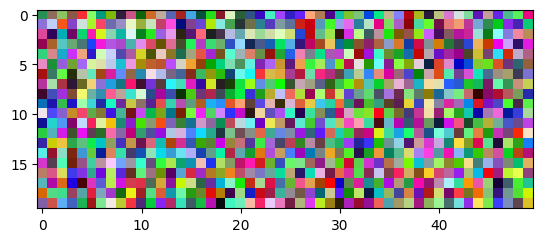

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img = np.random.randint(low=0, high=256, size= (20, 50, 3), dtype=np.uint8)
plt.imshow(img)
plt.show()




 - $\color{red}C=1$ for gray images
    - Or, `2D arrays can be gray images`

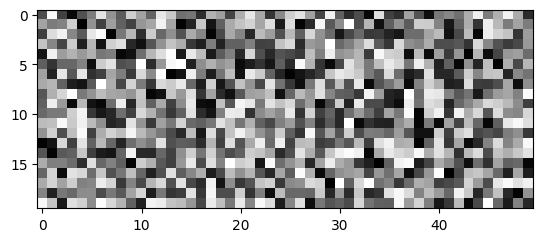

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img = np.random.randint(low=0, high=256, size= (20, 50), dtype=np.uint8)
# 2차원 이기에 흑백이라고 알려줘야함(cmap), plt 경우엔 안알려줘도 되긴하는데 패키지마다 다르기에 알려주는게 나음
plt.imshow(img, cmap='gray')
plt.show()

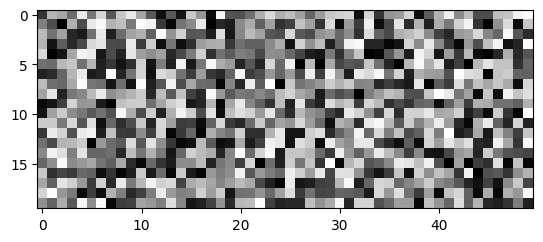

In [39]:
import numpy as np
import matplotlib.pyplot as plt

img = np.random.randint(low=0, high=256, size= (20, 50, 1), dtype=np.uint8)
plt.imshow(img, cmap='gray')
plt.show()

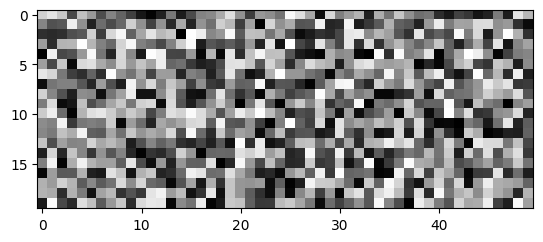

In [40]:
import numpy as np
import matplotlib.pyplot as plt

gray = np.random.randint(low=0, high=256, size= (20, 50, 1), dtype=np.uint8)
img = np.concatenate((gray, gray, gray), axis=2)
plt.imshow(img)
plt.show()

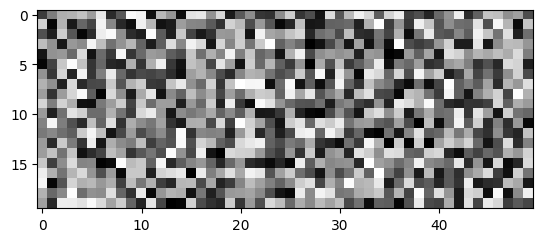

In [41]:
import numpy as np
import matplotlib.pyplot as plt

gray = np.random.randint(low=0, high=256, size= (20, 50, 1), dtype=np.uint8)
img = np.repeat(gray, 3, axis=2)
plt.imshow(img)
plt.show()

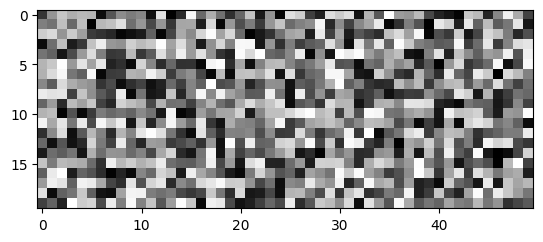

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

gray = np.random.randint(low=0, high=256, size= (20, 50), dtype=np.uint8)
# axis = 2 에 stack 을 하니  c= 3 와 같음
img = np.stack((gray, gray, gray), axis=2)
plt.imshow(img)
plt.show()

## 3. How to read and plot images

 #### matplotlib
   - matplotlib uses `float32 for PNG files` and `uint8 for other types` 

Shape		(418, 418, 4)
DataType	float32, 4Bytes/value
TotalSize	2795584


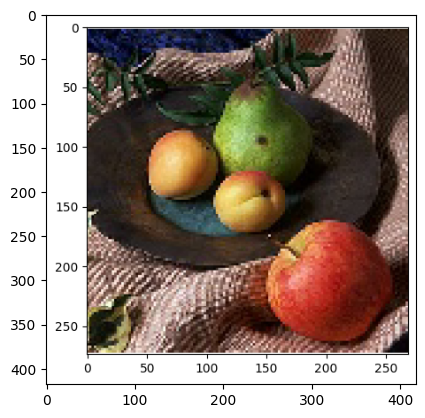

Shape		(418, 430, 4)
DataType	float32, 4Bytes/value
TotalSize	2875840


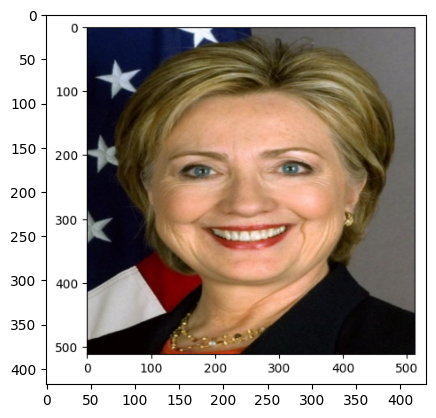

In [ ]:
import matplotlib.image as img
import matplotlib.pyplot as plt
import numpy as np



src = img.imread("images/apple.png")
print(f"Shape\t\t{src.shape}\n\
DataType\t{src.dtype}, {src.itemsize}Bytes/value\n\
TotalSize\t{src.nbytes}")

plt.imshow(src)
plt.show()

src = img.imread("images/Hillary.png")
print(f"Shape\t\t{src.shape}\n\
DataType\t{src.dtype}, {src.itemsize}Bytes/value\n\
TotalSize\t{src.nbytes}")

plt.imshow(src)
plt.show()

#### cv2
- $\color{red}\text{cv2.waitkey() and cv2.destroyAllWindows() are required}$ to prevent the kernel from being stuck in JupyterNotebook
- `cv2 uses uint8 only`

matplot 은 이미지 읽고 표시하는 기능만 있음 <br>
cv2 는 이미지 처리 하는 수많은 기능이 있기에 좋음 <br>
다만 cv2의 imshow 는 좀 복잡함 

In [7]:
import numpy as np
import cv2

src = cv2.imread("images/apple.png")
print( f"Shape\t\t{src.shape}\n\
DataType\t{src.dtype}, {src.itemsize}Bytes/value\n\
TotalSize\t{src.nbytes}")

cv2.namedWindow('1')
cv2.imshow('1', src)


src = cv2.imread("images/Hillary.png")
print()
print( f"Shape\t\t{src.shape}\n\
DataType\t{src.dtype}, {src.itemsize}Bytes/value\n\
TotalSize\t{src.nbytes}")
cv2.namedWindow('2')

cv2.imshow('2', src)
cv2.waitKey(0) # imshow 한 다음 반드시 waitKey 해줘야 창이 닫히지 않음
#0 은 무한대, 1 이상은 ms 단위로 창이 유지되는 시간
cv2.destroyAllWindows()

#namedWindow, imshow, waitKey, destroyAllWindows 는 opencv 에서 창을 띄우고 조작하는 함수들
#이 함수들은 함께 쓴다고 외우는게 좋음
cv2.waitKey(1) # Only for mac


#cv2 는 주피터 같은 인터렉티브 환경에선 커널이 죽을 수도 있기에 조심

Shape		(418, 418, 3)
DataType	uint8, 1Bytes/value
TotalSize	524172

Shape		(418, 430, 3)
DataType	uint8, 1Bytes/value
TotalSize	539220


-1

In [5]:
import cv2
import numpy as np
src = cv2.imread("images/apple.png")
src = src[::2, ::2, ::-1]
cv2.namedWindow('5')
cv2.imshow("5", src)
cv2.waitKey(0)
cv2.destroyAllWindows()

Mat 은 RGB 이나 cv2 는 BGR 로 저장하는것도 유의

## 4. `Be careful of data type`


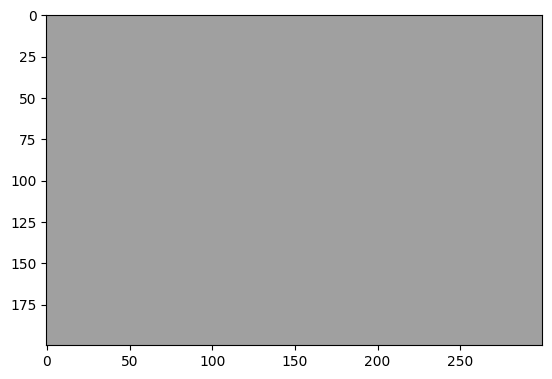

In [11]:
import numpy as np
import matplotlib.pyplot as plt

img_arr = np.full((200, 300, 3), 160, dtype=np.uint8)  # Remove the extra dimension
plt.imshow(img_arr)
plt.show()


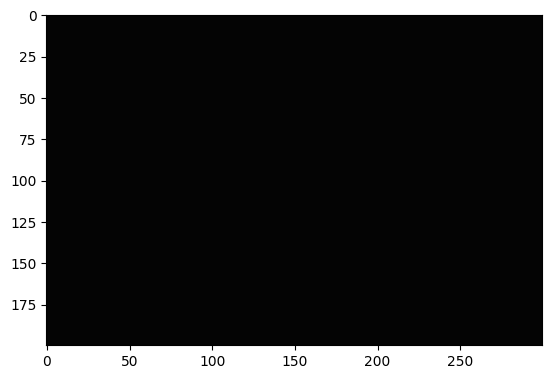

In [ ]:
dst = img_arr + 100
plt.imshow(dst)
plt.show()

# uint8 는 0~255 사이의 값이기에 255를 넘어가면 0으로 돌아감

In [61]:
print(dst.dtype)
print(dst[:3,:3,0])

uint8
[[4 4 4]
 [4 4 4]
 [4 4 4]]


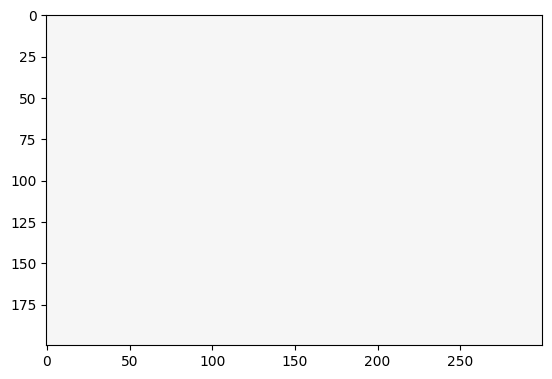

In [63]:
dst = img_arr - 170
plt.imshow(dst)
plt.show()

이러한 상황을 어떻게 예방하나?

<span style="color:yellow">

1. Change data type to a larger one before computation

2. Compute as you want

3. Return back the data type to `uint8`
</span>

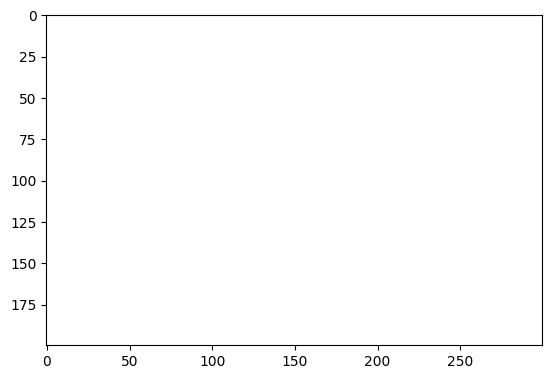

In [1]:
import numpy as np
import matplotlib.pyplot as plt


img_arr = np.full((200, 300, 3), 160, dtype=np.uint8)

# 1. Change data type
img_arr = img_arr.astype(np.float32)

# 2. Computation
dst = np.clip(img_arr + 190, 0, 255)
# clip 은 0~255 사이의 값으로 만들어주는 함수, dst = img_arr + 190 만 하면 255를 넘어가는 값이 생기기에 clip 으로 255로 만들어줌

# 3. Original data type
dst = dst.astype(np.uint8)


plt.imshow(dst)
plt.show()